# Assignment 1



## Question 1:
{method, implementation, answer}

Examine the value of sparse matricies by comparing the approximate computational efficiencies of sparse and dense solvers (on the same system). Use the %timeit function to approximate the complexity.

HINT: Refer to the lecture notes on how to generate, store, and apply sparse solvers.  

In [6]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import scipy.linalg as la

def make_system(n, density=0.001):
    # Sparse, diagonally dominant matrix (e.g. from a discretized PDE)
    A_sparse = sp.diags([-1, 2, -1], [-1, 0, 1], shape=(n, n), format='csr')
    b = np.random.rand(n)
    return A_sparse, b

n = 2000
A_sparse, b = make_system(n)
A_dense = A_sparse.toarray()

print("Sparse solve:")
%timeit spla.spsolve(A_sparse, b)

print("Dense solve:")
%timeit la.solve(A_dense, b)

Sparse solve:
932 µs ± 239 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
Dense solve:
6.47 ms ± 81.1 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


## Question 2

Consider the truss:

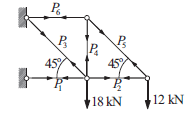


### 2a) Write the linear system for the tensions $P_i$ as equations and in matrix form
To acheive equilibrium for the system, the sum of all forces are 0. So, $\Sigma F x = 0$ and $\Sigma F y = 0$. We can describe the points as:


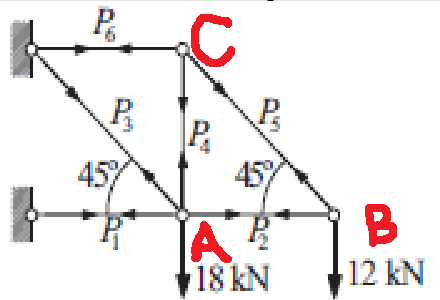

The equations can be written as:

C:

$\Sigma F x = 0: \quad -P_6 + \sin(45°)P_5 = 0$

$\Sigma F y = 0: \quad -P_4 - \sin(45°)P_5 = 0$



A:

$\Sigma F x = 0: \quad -P_1 + P_2 - \sin(45°)P_3 = 0$

$\Sigma F y = 0: \quad \sin(45°)P_3 + P_4 = 18$



B:

$\Sigma F x = 0: \quad -P_2 - \sin(45°)P_5 = 0$

$\Sigma F y = 0: \quad \sin(45°)P_5 = 12$


In matrix form can be displayed as:

$A\mathbf{P} = \mathbf{b}, \quad \mathbf{P} = [P_1, P_2, P_3, P_4, P_5, P_6]^T$


### 2b) Solve for $P_i$ using LU decomposition and substitution.
Factor A=LU (Gaussian elimination with partial pivoting), then solve Ly=b Ly=b (forward sub) and
UP=y
UP=y (back sub) via lu_solve.

In [8]:
import numpy as np
from scipy.linalg import lu_factor, lu_solve

s = 1/np.sqrt(2)

A = np.array([
    [ 0,  0,  0,  0,  s, -1],
    [ 0,  0,  0, -1, -s,  0],
    [-1,  1, -s,  0,  0,  0],
    [ 0,  0,  s,  1,  0,  0],
    [ 0, -1,  0,  0, -s,  0],
    [ 0,  0,  0,  0,  s,  0]
])

b = np.array([0, 0, 0, 18, 0, 12])

lu, piv = lu_factor(A)       # LU decomposition (done once)
P = lu_solve((lu, piv), b)   # forward + back substitution

for i, val in enumerate(P, start=1):
    print(f"P{i} = {val:.4f} kN")

P1 = -42.0000 kN
P2 = -12.0000 kN
P3 = 42.4264 kN
P4 = -12.0000 kN
P5 = 16.9706 kN
P6 = 12.0000 kN


### 2c)  Double the loads (18 kN and 12 kN) and solve for $P_i$ again *without refactoring*.
{answer}

In [9]:
b2 = np.array([0, 0, 0, 36, 0, 24])   # doubled loads
P2_sol = lu_solve((lu, piv), b2)      # reuse factors — no refactor!

for i, val in enumerate(P2_sol, start=1):
    print(f"P{i} = {val:.4f} kN")

P1 = -84.0000 kN
P2 = -24.0000 kN
P3 = 84.8528 kN
P4 = -24.0000 kN
P5 = 33.9411 kN
P6 = 24.0000 kN


## Question 3

Consider the matrix:

$$ A = \begin{bmatrix} 1 & 2 \\ 3 & 4 \end{bmatrix}$$

## 3a) Calculate the condition number of A
{answer}

In [10]:
import numpy as np

A = np.array([[1, 3],
              [2, 4]])

cond_2   = np.linalg.cond(A)          # 2-norm (default)
cond_inf = np.linalg.cond(A, np.inf)  # infinity-norm

print(f"cond_2(A)   = {cond_2:.4f}")
print(f"cond_inf(A) = {cond_inf:.4f}")

cond_2(A)   = 14.9330
cond_inf(A) = 21.0000


## 3b) Let's use a preconditioner matrix $P$ to improve the condition number of the product $P^{-1} A$. Give 2 examples of $P$ that improve the condition number.

Can you identify the 'perfect' preconditioner? (Consider the easiest matrix to solve!)
{answer, answer}

In [11]:
# Jacobi preconditioner
P1 = np.diag(np.diag(A))
M1 = np.linalg.inv(P1) @ A
print("Jacobi P:\n", P1)
print("cond(P1^-1 A) =", np.linalg.cond(M1))

# Gauss-Seidel preconditioner
P2 = np.tril(A)
M2 = np.linalg.inv(P2) @ A
print("\nGauss-Seidel P:\n", P2)
print("cond(P2^-1 A) =", np.linalg.cond(M2))

Jacobi P:
 [[1 0]
 [0 4]]
cond(P1^-1 A) = 22.45546741550749

Gauss-Seidel P:
 [[1 0]
 [2 4]]
cond(P2^-1 A) = 20.451102881551588
